228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.
Dataset loaded with 1 classes: ['flower_photos']
Sample image shape: (180, 180, 3)


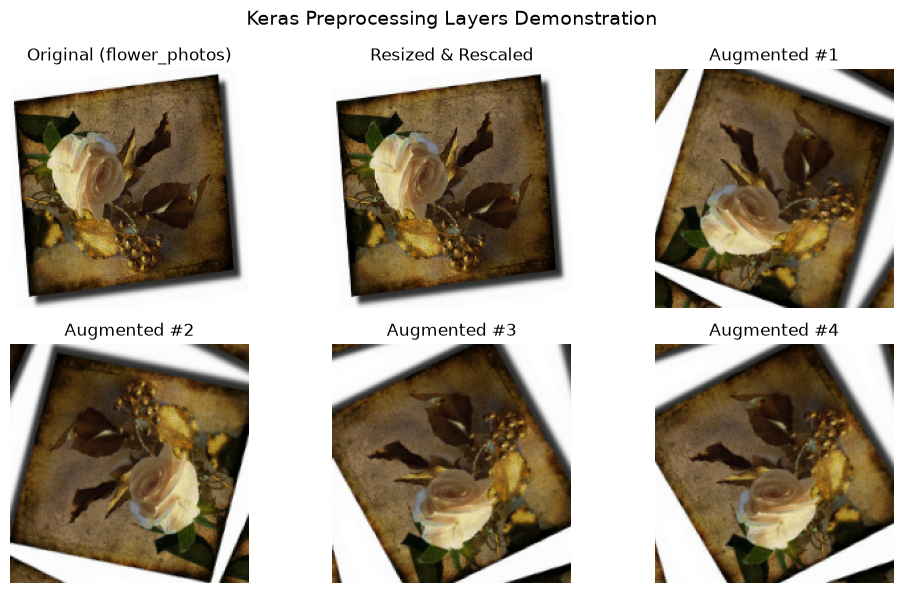

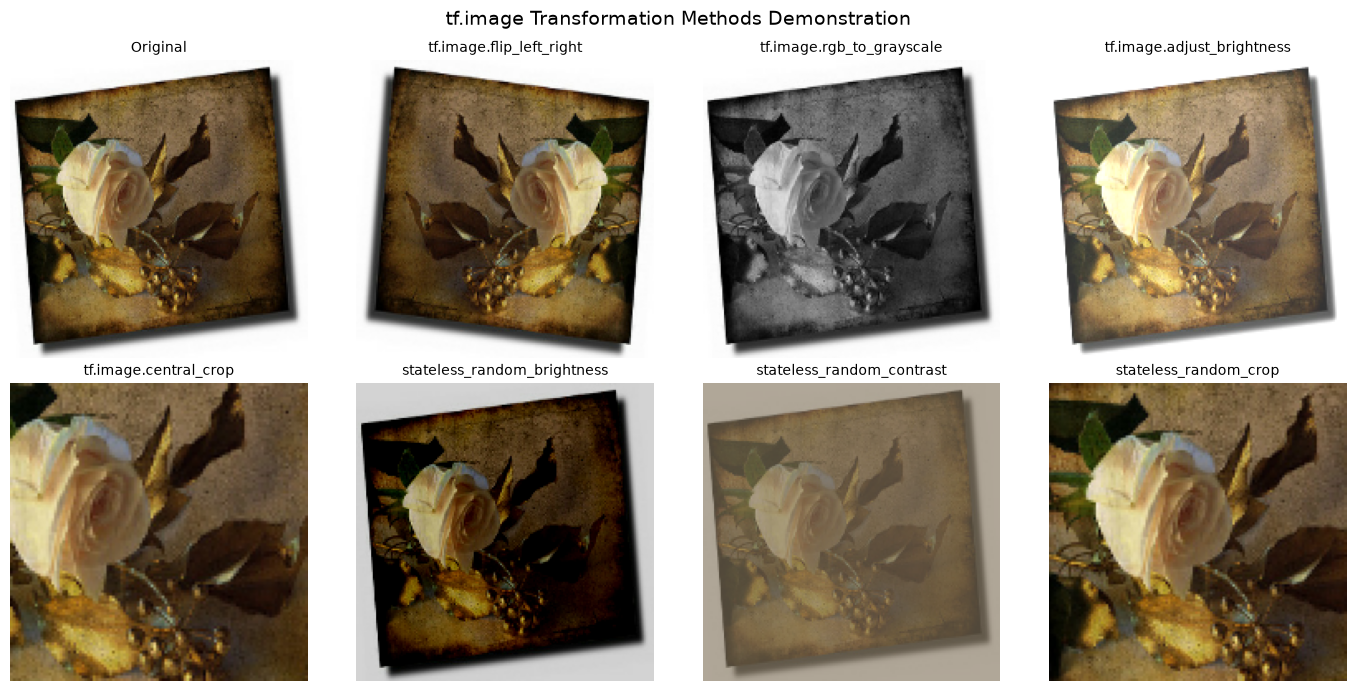

In [3]:
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

# ==============================================================================
# 1. Download and Load the Flowers Dataset (No tfds required)
# ==============================================================================
print("Downloading tf_flowers dataset...")
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

IMG_SIZE = 180
batch_size = 32

# Load train and validation splits using image_dataset_from_directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Extract a single sample image tensor for demonstration
for images, labels in train_ds.take(1):
    image = tf.cast(images[0], tf.uint8)
    label = labels[0]
    break

print(f"Dataset loaded with {num_classes} classes: {class_names}")
print("Sample image shape:", image.shape)


# ==============================================================================
# 2. Keras Preprocessing Layers (Resizing, Rescaling, RandomFlip, RandomRotation)
# ==============================================================================
# Sequential model combining Resizing and Rescaling
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMG_SIZE, IMG_SIZE),
    layers.Rescaling(1.0 / 255)
])

# Sequential model for Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

# Batch single image for layer processing
image_batched = tf.cast(tf.expand_dims(image, 0), tf.float32)

# Apply preprocessing and augmentation
resized_rescaled_image = resize_and_rescale(image_batched)
augmented_images = [data_augmentation(image_batched) for _ in range(4)]

# Display Keras Preprocessing Layer Results
plt.figure(figsize=(10, 6))
plt.subplot(2, 3, 1)
plt.title(f"Original ({class_names[label]})")
plt.imshow(image)
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Resized & Rescaled")
plt.imshow(resized_rescaled_image[0])
plt.axis("off")

for i in range(4):
    plt.subplot(2, 3, i + 3)
    plt.title(f"Augmented #{i+1}")
    plt.imshow(augmented_images[i][0] / 255.0)
    plt.axis("off")

plt.suptitle("Keras Preprocessing Layers Demonstration", fontsize=14)
plt.tight_layout()
plt.show()


# ==============================================================================
# 3. Low-Level tf.image Methods & Stateless Operations
# ==============================================================================
# Deterministic tf.image methods
flipped_lr = tf.image.flip_left_right(image)
grayscaled = tf.squeeze(tf.image.rgb_to_grayscale(image))
brightened = tf.image.adjust_brightness(image, delta=0.2)
central_cropped = tf.image.central_crop(image, central_fraction=0.6)

# Functional stateless random ops (require a seed tensor of shape (2,))
seed = (42, 0)
stateless_brightness = tf.image.stateless_random_brightness(image, max_delta=0.4, seed=seed)
stateless_contrast = tf.image.stateless_random_contrast(image, lower=0.2, upper=0.8, seed=seed)
stateless_crop = tf.image.stateless_random_crop(image, size=[120, 120, 3], seed=seed)

# Helper function to visualize tf.image results
def visualize_tf_image_ops():
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    ops = [
        ("Original", image),
        ("tf.image.flip_left_right", flipped_lr),
        ("tf.image.rgb_to_grayscale", grayscaled),
        ("tf.image.adjust_brightness", brightened),
        ("tf.image.central_crop", central_cropped),
        ("stateless_random_brightness", stateless_brightness),
        ("stateless_random_contrast", stateless_contrast),
        ("stateless_random_crop", stateless_crop)
    ]
    
    for idx, (title, img) in enumerate(ops):
        r, c = divmod(idx, 4)
        ax = axes[r, c]
        if len(img.shape) == 2 or img.shape[-1] == 1:
            ax.imshow(tf.squeeze(img), cmap='gray')
        else:
            ax.imshow(img)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
        
    plt.suptitle("tf.image Transformation Methods Demonstration", fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_tf_image_ops()